## Intrinsic decoherence dynamics in the three-coupled harmonic oscillators interaction
### Comparison notebook
___
Authors: Alejandro R. Urzúa & Héctor M. Moya-Cessa

Coder: Alejandro R. Urzúa

 [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)
___

The purpose of this notebook is to solve the same Hamiltonian of the paper, but without the intrinsic decoherence methodology, just with the Scrh\"odinger equation, and perhaps, a master equation.

Given the Hamiltonian 

$$\hat{H} = \omega\left(\hat{a}_{1}^{\dagger}\hat{a}_{1} + \hat{a}_{2}^{\dagger}\hat{a}_{2} + \hat{a}_{3}^{\dagger}\hat{a}_{3}\right) + \lambda\left(\hat{a}_{1}^{\dagger}\hat{a}_{2} + \hat{a}_{2}^{\dagger}\hat{a}_{1}\right)+ g\left[\hat{a}_{3}\left(\hat{a}_{1}^{\dagger}+\hat{a}_{2}^{\dagger}\right)+\hat{a}_{3}^{\dagger}(\hat{a}_{1}+\hat{a}_{2})\right],$$

we solve it using 

$$\mathrm{i}\frac{\partial |\psi\rangle}{\partial t} = \hat{H}|\psi\rangle,$$

for the same initial condition $|\psi\rangle = |\alpha\rangle_{1}|0\rangle_{2}|0\rangle_{3}$.

In [1]:
# Calling the package to handle the quantum mechanics operations
using QuantumOptics

In [2]:
# Calling the plotting suite
using PyPlot
using LaTeXStrings
ion()

In [9]:
# Dimension of the Fock space. Each oscillator support the same number of modes
const dim = 30

fbasis = FockBasis(dim);

In [4]:
# Annihilation and number operators
a = destroy(fbasis)
n = number(fbasis);

In [6]:
# Function to give the tensor versions of the operators for the three-oscillators
function aT(pos)
	if pos == 1
		return tensor(a, identityoperator(fbasis), identityoperator(fbasis))
	elseif pos == 2
		return tensor(identityoperator(fbasis), a, identityoperator(fbasis))
	elseif pos == 3
		return tensor(identityoperator(fbasis), identityoperator(fbasis), a)
	end
end;

In [8]:
function nT(pos)
	if pos == 1
		return tensor(n, identityoperator(fbasis), identityoperator(fbasis))
	elseif pos == 2
		return tensor(identityoperator(fbasis), n, identityoperator(fbasis))
	elseif pos == 3
		return tensor(identityoperator(fbasis), identityoperator(fbasis), n)
	end
end;

In [16]:
Hfree(ω) = ω * (nT(1) + nT(2) + nT(3)) # Free part of the Hamiltonian

Hl(λ) = λ * (dagger(aT(1)) * aT(2) + dagger(aT(2)) * aT(1)) # Interaction between 1 and 2

Hg(g) = g * (aT(3) * (dagger(aT(1)) + dagger(aT(2))) + dagger(aT(3)) * (aT(1) + aT(2))) # Interaction between 1, 2, and 3

H(ω, λ, g) = Hfree(ω) + Hl(λ) + Hg(g); # Complete Hamiltonian

In [17]:
# Initial condition
ψ₀(α) = tensor(coherentstate(fbasis, α), fockstate(fbasis, 0), fockstate(fbasis, 0));

In [34]:
# Evolution time
tlist = [0:0.1:25;];

In [35]:
# Solving the Schrödinger equation
tout, ψₜ = timeevolution.schroedinger(tlist, ψ₀(4), H(4, 0.5, 0.1));

In [36]:
# Expectation values for the photon number in each oscillator
expn1 = expect(nT(1), ψₜ)
expn2 = expect(nT(2), ψₜ)
expn3 = expect(nT(3), ψₜ);

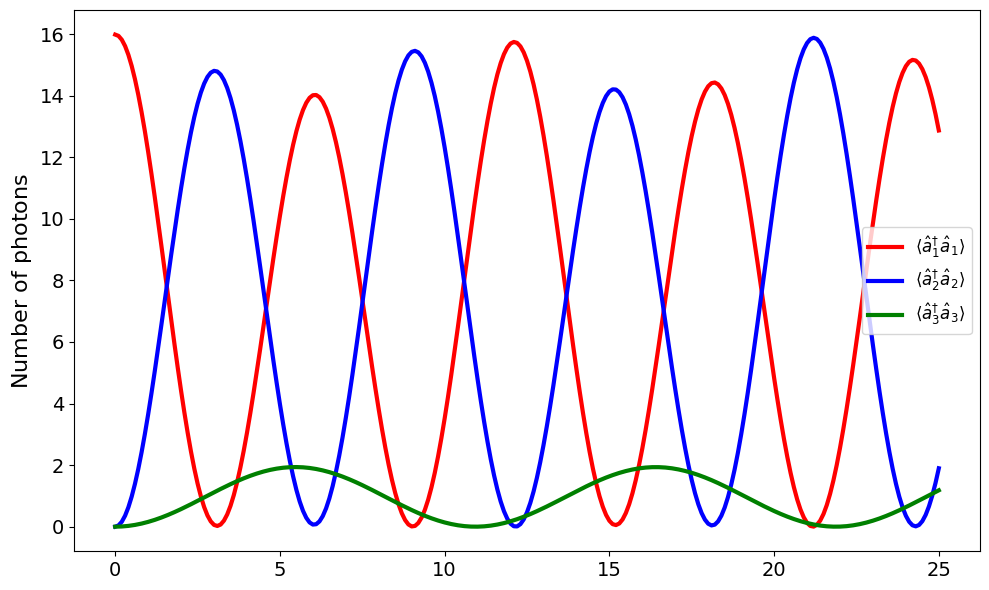

In [37]:
fig = figure(figsize = (10,6))
ax = gca()

	ax.plot(tout, expn1, "r", lw = "3", label = L"\langle \hat{a}_{1}^{\dagger}\hat{a}_{1} \rangle")
	ax.plot(tout, expn2, "b", lw = "3", label = L"\langle \hat{a}_{2}^{\dagger}\hat{a}_{2} \rangle")
	ax.plot(tout, expn3, "g", lw = "3", label = L"\langle \hat{a}_{3}^{\dagger}\hat{a}_{3} \rangle")

ax.set_ylabel(L"\rm{Number\ of\ photons}", fontsize = 16)
setp(ax.get_xticklabels(), fontsize = 14)
setp(ax.get_yticklabels(), fontsize = 14)
ax.legend(fontsize = 12)

tight_layout()

We can see, that there's no damping in the dynamics of the photon counting in each oscillator, only the ordinal interchange between them